In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import flammkuchen as fl

from nutil.plot import paperStyle

/data/du92wufe/.conda/envs/airway/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [65]:
from graphviz import Graph

In [8]:
# specify GA results folder here
ga_run = 'ga_20221122-232640_DEV_RUN'

path = Path('Results/' + ga_run)

In [9]:
with open(path / 'params.json') as f:
    params = json.loads(f.read())

In [215]:
def show_architecture(chromosome_path):
    with open(chromosome_path, "r") as f:
        chromosome = json.loads(f.read())
    
    chromosome = list(chromosome)
    #chromosome.reverse()
    #print(chromosome)
    
    g = Graph('G', filename='process.gv')#, graph_attr={'rankdir':'LR'})#, engine='sfdp')  
    previous_layer = chromosome[0]['layer']
    for gene in chromosome[1::]:
        g.edge(gene['layer'], previous_layer, constraint='false')
        previous_layer = gene['layer']
        
def plot_results_table(path, ax):
    with open(path) as f:
        d = json.loads(f.read()) 
    ax.axis('off')
    ax.axis('tight')
    table = ax.table(cellText=[[str(d[key])] for key in d], rowLabels=[str(key) for key in d], loc='center') 
    table.scale(1.5, 1)  # may help
    
def plot_power_consumption(path, ax):
    data = pd.read_csv(path)
    values = np.asarray(data["Power Consumption"])
    ax.plot(values, color='magenta')
    
def plot_training(path, ax_loss, ax_acc):
    history = fl.load(path)
    #print(history)
    ax_loss.plot(history['loss'], marker="x")
    ax_loss.plot(history['val_loss'], marker="x")
    #ax_loss.legend()
    
    ax_acc.plot(history['accuracy'], label="train", marker="x")
    ax_acc.plot(history['val_accuracy'], label="val", marker="x")
    ax_acc.legend()
    
def plot_summary_individual(path):
    #show_architecture(path / "chromosome.json")
    fig, axes = plt.subplots(1, 4)  
    plt.tight_layout()
    plot_results_table(path / "results.json", axes[0]) 
    plot_power_consumption(path / "power_measurements.csv", axes[1])
    plot_training(path / "history.fl", axes[2], axes[3])
    
    plt.show()

## Plot best individual of each generation

In [172]:
best_individuals = pd.read_csv(path / "best_individual_each_generation.csv", names=["Generation", "Individual", "Fitness"], delimiter=",")
best_individuals["Generation"] = best_individuals["Generation"].apply(lambda x: x.replace(": ", "_"))

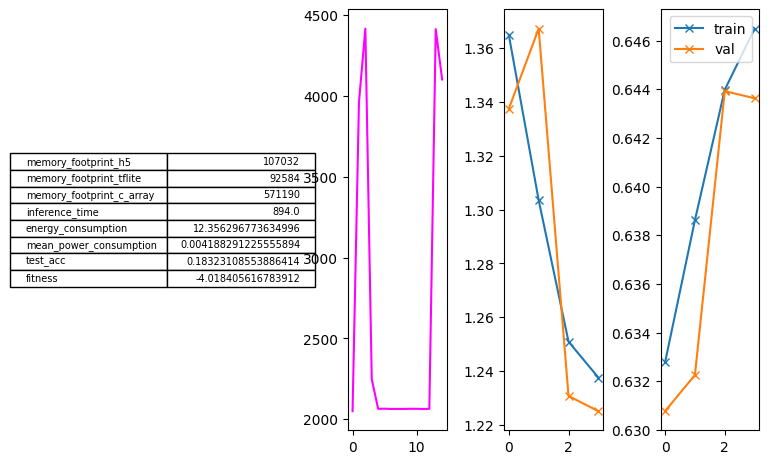

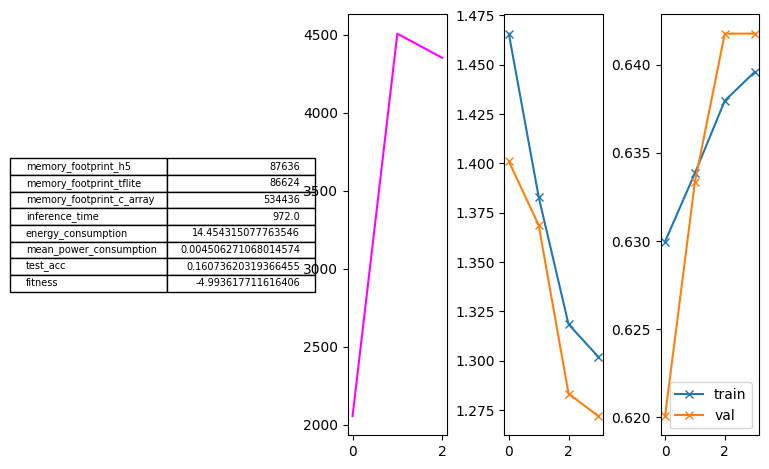

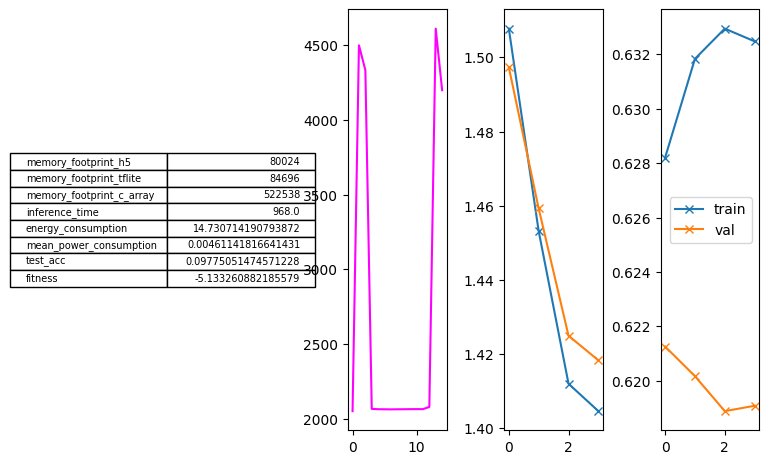

In [216]:
for idx, row in best_individuals.iterrows():
    path_individual = path / row["Generation"] / row["Individual"]
    plot_summary_individual(path_individual)
    if idx == 2:
        break


In [34]:
def plot_generation_summary(gen_path):
    individuals = os.listdir(gen_path)
    epochs_trained = []
    power_consumptions = []
    memory_footprints = []
    for ind in individuals:
        ind_path = gen_path / ind
        
        # nb epochs
        history = fl.load(ind_path / "history.fl")
        epochs_trained.append(len(history["val_loss"]))
        
        # power measurements and size of network
        with open(gen_path / ind / "results.json") as f:
            d = json.loads(f.read()) 
          
        try:
            power_consumption = d["mean_power_consumption"]
            power_consumption = float(power_consumption)        
            power_consumptions.append(power_consumption)
            memory_footprints.append(d["memory_footprint_tflite"])
        except:
            print(d["energy_consumption"])
            pass
        
        
    #plt.scatter(np.ones(len(epochs_trained))+np.random.uniform(-0.2, 0.2, len(epochs_trained)), epochs_trained)
    #plt.show()
    
    plt.scatter(power_consumptions, memory_footprints)
    #plt.xlim(0.0038, 0.0048)
    plt.ylabel("Memory footprint bytes")
    plt.xlabel("power cons A")
    

In [40]:
from ipywidgets import interact, IntSlider

In [42]:
@interact
def showGen(g=IntSlider(1,1,20)):
    gen = f"Generation_{g}"
    plot_generation_summary(path / gen)

interactive(children=(IntSlider(value=1, description='g', max=20, min=1), Output()), _dom_classes=('widget-int…

In [6]:
fitnesses_all = []
for i in range(1, params['generations'] + 1):
    fitnesses_generation = []
    try:
        for individual in os.listdir(path + f'/Generation_{i}'):
            with open(path + f'/Generation_{i}/{individual}/results.json') as f:
                results = json.loads(f.read())
                try:
                    fitnesses_generation.append(results['fitness'])
                except:
                    # this means that there is no fitness in the file 
                    # because the model was too big and so the fitness was not determined
                    fitnesses_generation.append(0)
        fitnesses_all.append(fitnesses_generation)
    except:
        pass

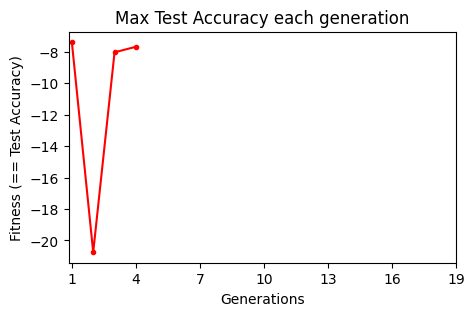

In [7]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(fitnesses_all) + 1), np.max(fitnesses_all, axis=1), 'r.-')
#plt.errorbar(np.arange(1, len(fitnesses_all) + 1), np.max(fitnesses_all, axis=1), np.std(fitnesses_all, axis=1))
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.title("Max Test Accuracy each generation")
plt.show()

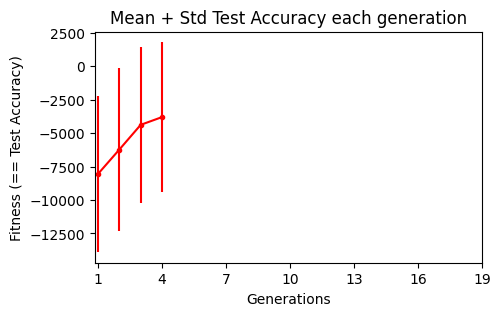

In [8]:
plt.figure(figsize=(5, 3))
plt.errorbar(np.arange(1, len(fitnesses_all) + 1), np.mean(fitnesses_all, axis=1), np.std(fitnesses_all, axis=1), fmt='r.-')
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.title("Mean + Std Fitness each generation")
plt.show()

In [12]:
memory_footprints_all = []
for i in range(1, params['generations'] + 1):
    footprints_generation = []
    try:
        for individual in os.listdir(path + f'/Generation_{i}'):
            with open(path + f'/Generation_{i}/{individual}/results.json') as f:
                results = json.loads(f.read())         
                try:
                    footprints_generation.append(results['memory_footprint_tflite'])
                except:
                    # this means that there is no fitness in the file 
                    # because the model was too big and so the fitness was not determined
                    footprints_generation.append(0)
        memory_footprints_all.append(footprints_generation)
    except:
        pass

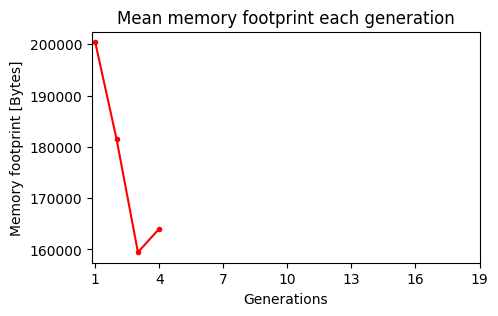

In [13]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(memory_footprints_all) + 1), np.mean(memory_footprints_all, axis=1), 'r.-')
#plt.errorbar(np.arange(1, len(memory_footprints_all) + 1), np.mean(memory_footprints_all, axis=1), np.std(memory_footprints_all, axis=1))
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Memory footprint [Bytes]')
plt.title("Mean memory footprint each generation")
plt.show()

In [2]:
import nvidia_smi

In [3]:
nvidia_smi.nvmlInit()

handle = nvidia_smi.nvmlDeviceGetHandleByIndex(0)

In [4]:
info = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)

print("Total memory:", info.total)
print("Free memory:", info.free)
print("Used memory:", info.used)

nvidia_smi.nvmlShutdown()

Total memory: 25434652672
Free memory: 12030509056
Used memory: 13404143616
